# 第60篇：毕业大项目——端到端机器学习完整实战

> 这是「数据分析从入门到精通」系列的第 60 篇，也是整个系列的大结局。60 篇走完，从 NumPy 到机器学习，全部知识在这篇大项目里集中上阵——端到端完整跑通一个真实的机器学习项目，这就是你的毕业答卷。

---

嗨，早上好啊，我是小荷，好几天不见啦慌不慌~ 放心吧，我会让你毕业的😄 这不，项目来啦~ 

这一篇的**数据准备**部分要好好看哦，有一些重要的小技巧。

## 一、项目概述

### 1.1 项目背景

假设你是某电商公司的数据分析师，老板给你布置了一个任务：**预测哪些用户会在未来30天内下单**，以便运营团队精准投放优惠券。

这就是典型的**二分类问题**：用户会购买（1）vs 不会购买（0）。

### 1.2 项目目标

完成一个**端到端的机器学习项目**，包括：
- ✅ 数据收集与探索
- ✅ 数据清洗与预处理
- ✅ 特征工程
- ✅ 模型训练与调优
- ✅ 模型评估与解释
- ✅ 生成业务洞察报告

### 1.3 项目结构

一个清晰的项目结构，是工程化的第一步：


In [ ]:
📁 e-commerce-prediction/
├── 📄 data/
│   ├── raw_data.csv          # 原始数据
│   └── processed_data.csv    # 清洗后数据
├── 📄 notebooks/
│   ├── 01_eda.ipynb          # 探索性分析
│   ├── 02_feature.ipynb      # 特征工程
│   └── 03_modeling.ipynb     # 建模
├── 📄 src/
│   ├── preprocess.py         # 数据预处理模块
│   ├── features.py           # 特征工程模块
│   └── model.py              # 模型训练模块
├── 📄 models/                # 保存的模型
├── 📄 reports/               # 分析报告
└── 📄 main.py                # 主流程脚本


---

## 二、数据准备

### 2.1 模拟真实电商数据

模拟生成电商平台 5000 条用户全维度样本数据集，包含用户基础属性、注册生命周期、90 天中长期行为、7 天短期行为，最后生成二分类标签is_active（用户是否活跃），可用于用户分群、活跃度预测、流失建模等机器学习任务。

**2.1.1 基础数据**
- 基础画像：ID、注册时间、年龄、性别、城市层级、设备；
- 生命周期：注册到统计日总天数；

**2.1.2 行为特征数据**

按时间分层：90 天长期行为 / 7 天短期行为
- 中长期行为（90 天）：会话、浏览、时长、订单、消费；
- 短期行为（7 天）：近期会话、浏览、加购、收藏，建模中短期行为权重更高；

**2.1.3 随机分布设计思路**
- 注册时间：指数分布，模拟平台新用户多、老用户少；
- 会话 / 订单 / 加购：泊松分布（单位时间或空间内稀有事件发生次数的概率分布），贴合计数类业务数据；
- 时长、金额：指数 / 均匀分布，还原真实消费行为长尾特征。

In [446]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# -------------------------- 绘图全局配置 --------------------------
# 设置图表中文显示字体，依次微软雅黑、黑体、默认英文字体兜底
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei', 'DejaVu Sans']
# 解决坐标轴负号显示乱码方框的问题
plt.rcParams['axes.unicode_minus'] = False

# 设置numpy随机种子42，保证每次运行生成的随机数据完全一致，可复现
np.random.seed(42)

# 设定总用户样本量5000条
n_users = 5000

# -------------------------- 生成用户注册时间 --------------------------
# 生成指数分布随机天数，均值180天，模拟注册时间偏近期（新用户更多）
registration_dates = [
    # 以2024-01-01为基准，叠加随机天数生成注册日期
    datetime(2024, 1, 1) + timedelta(days=int(x))
    for x in np.random.exponential(180, n_users) # 生成指数分布随机数,均值180天,一次性生成 n_users 个数字
]
# 限制注册日期不超过2026-06-23，防止出现未来时间
registration_dates = [min(d, datetime(2026, 6, 23)) for d in registration_dates]

# -------------------------- 构建用户基础信息DataFrame --------------------------
data = pd.DataFrame({
    # 用户ID，从10001开始自增5000个
    'user_id': range(10001, 10001 + n_users),
    # 上面生成的注册时间列表
    'registration_date': registration_dates,
    # 年龄：18~64随机整数
    'age': np.random.randint(18, 65, n_users),
    # 性别：男M概率45%，女F概率55%
    'gender': np.random.choice(['M', 'F'], n_users, p=[0.45, 0.55]),
    # 城市层级：一线15%、二线35%、三线35%、四线及以下15%
    'city_tier': np.random.choice([1, 2, 3, 4], n_users, p=[0.15, 0.35, 0.35, 0.15]),
    # 设备类型：iOS40%、安卓45%、PC15%
    'device_type': np.random.choice(['iOS', 'Android', 'PC'], n_users, p=[0.4, 0.45, 0.15]),
    'noise_feature':  np.random.randint(0, 10, n_users),
})

# -------------------------- 计算用户生命周期天数 --------------------------
# 以2026-01-01为统计截止日，计算从注册到统计日相隔天数
data['lifetime_days'] = (datetime(2026, 6, 23) - data['registration_date']).dt.days

# -------------------------- 生成过去90天中长期行为特征 --------------------------
# 90天总会话数：泊松分布，用户生命周期越长，会话期望越高
data['total_sessions_90d'] = np.random.poisson(data['lifetime_days'] * 0.3, n_users)
# 90天总页面浏览量：会话数 × 单次会话3~15页随机值
data['total_pageviews_90d'] = data['total_sessions_90d'] * np.random.uniform(3, 15, n_users)
# 平均会话时长（秒）：指数分布，大部分会话短，少量长会话
data['avg_session_duration'] = np.random.exponential(300, n_users)
# 90天下单总次数：泊松分布，会话越多下单期望越高
data['total_orders_90d'] = np.random.poisson(data['total_sessions_90d'] * 0.05, n_users)
# 90天总消费金额：下单次数 × 单订单50~500元随机金额
data['total_spent_90d'] = data['total_orders_90d'] * np.random.uniform(50, 500, n_users)

# -------------------------- 生成最近7天短期行为特征（高权重近期行为） --------------------------
# 近7天会话量：基于90天总量按比例缩放，叠加0.5~1.5随机扰动，转整数
data['sessions_7d'] = (data['total_sessions_90d'] * 0.3 * np.random.uniform(0.5, 1.5, n_users)).astype(int)
# 近7天页面浏览量：7天会话 × 单次3~12页
data['pageviews_7d'] = data['sessions_7d'] * np.random.uniform(3, 12, n_users)
# 近7天加购商品数：泊松分布，会话越多加购期望越高
data['cart_adds_7d'] = np.random.poisson(data['sessions_7d'] * 0.2, n_users)
# 近7天收藏商品数：泊松分布，收藏概率低于加购
data['wishlist_adds_7d'] = np.random.poisson(data['sessions_7d'] * 0.1, n_users)

# -------------------------- 构建用户活跃标签（分类标签） --------------------------
# 近7天有会话=活跃用户(1)，无会话=流失/不活跃(0)
data['is_active'] = (data['sessions_7d'] > 0).astype(int)

# -------------------------- 打印数据集基础信息 --------------------------
print("📊 数据集概览：")
# 输出总用户行数
print(f"用户数量: {len(data)}")
# 输出特征总列数
print(f"特征数量: {len(data.columns)}")
# 空行分隔
print("\n前5行数据：")
# 打印数据集前5行预览
print(data.head())

📊 数据集概览：
用户数量: 5000
特征数量: 18

前5行数据：
   user_id registration_date  age gender  city_tier device_type  \
0    10001        2024-03-25   57      M          3     Android   
1    10002        2025-06-25   24      M          1     Android   
2    10003        2024-08-25   49      F          2          PC   
3    10004        2024-06-13   36      M          1          PC   
4    10005        2024-01-31   23      F          1          PC   

   noise_feature  lifetime_days  total_sessions_90d  total_pageviews_90d  \
0              1            820                 246          1055.022902   
1              9            363                 105          1410.892936   
2              4            667                 192          2394.479896   
3              0            740                 213           741.960763   
4              7            874                 270           880.785566   

   avg_session_duration  total_orders_90d  total_spent_90d  sessions_7d  \
0             51.141534     

### 2.2 创建目标变量

创建模型预测目标变量：用户未来30天是否产生下单行为（二分类标签）。

我们要让目标变量包含复杂非线性关系，这样更适合树模型去捕捉模式。

主要是通过Sigmoid函数模拟真实业务逻辑，根据年龄、历史行为等计算用户下单概率。

具体逻辑：

1. 整体公式是 Sigmoid 函数：p = 1/(1+e^(-z))，输出区间固定 0~1，天然代表概率；
2. z 由多个人工设定权重的业务特征线性叠加构成
   - 年龄的非线性影响 (倒U型曲线) ：`age_effect = -0.003 * (data['age'] - 30) ** 2`，模拟真实的消费主力人群分布。购买力或意愿在 30岁左右达到顶峰，过年轻（没钱/没需求）或过年长（需求固化/流失）都会导致购买概率下降。这是一个典型的二次函数关系，线性模型很难直接拟合，需要特征变换或非线性模型。
   - 历史消费的边际递减效应：`spent_effect = 0.05 * np.log1p(data['total_spent_90d'])`，使用了 log1p 对数变换。这意味着虽然花钱越多购买意愿越强，但增长是放缓的。从0花到100元的提升效果，远大于从10000花到10100元。这符合经济学中的边际效用递减规律。
   - 高阶交互特征：`(avg_page_per_session > 5) & (cart_adds_7d > 2`，定义了一个强转化信号：只有当用户“看得深”（每次会话看很多页）并且“近期有动作”（加购多）时，才给予巨大的权重加分。这种“与”逻辑是树模型（如XGBoost、Random Forest）的强项，而逻辑回归如果不手动构造交叉特征则无法学到这一点。
   - 加入外部阻力：`np.random.choice([0, -2], ... p=[0.9, 0.1])`，模拟不可控的外部因素（如突然断网、竞品促销、心情不好），给10%的用户泼冷水。
   - 正态随机噪声：`np.random.normal(0, 1.2, ...)`，确保数据既有规律可循（信噪比合适），又不会太容易预测（避免过拟合）。
   - 截距项起到了“阈值”作用，确保在没有强特征驱动的情况下，基础购买率维持在一个较低的水平（模拟现实中转化率通常不高的情况）
4. 以 0.5 为阈值划分二分类标签，构造用于训练的监督学习目标：用户复购预测。

In [447]:
# ── 创建目标变量：未来30天是否下单 ──

# 1. 年龄：倒U型，峰值在30岁附近 
age_effect = -0.003 * (data['age'] - 30) ** 2  # 略微压缩系数

# 2. 历史消费：对数边际递减 
spent_effect = 0.05 * np.log1p(data['total_spent_90d'])

# 3. 高意向信号：每次会话浏览页数 > 5 且 近7天有加购
#    这是真正的交互非线性，树能自动学到，逻辑回归学不到
data['avg_page_per_session_90d'] = (
    data['total_pageviews_90d'] / (data['total_sessions_90d'] + 1)
)
complex_signal = np.where(
    (data['avg_page_per_session_90d'] > 5) & (data['cart_adds_7d'] > 2),
    1.5,   # 原来是3.0，过大会让这个条件直接决定标签，降低到1.5
    0.0
)

# 4. 外部阻力 ── 保持不变
external_resistance = np.random.choice([0, -2], n_users, p=[0.9, 0.1])
# 原来是 -3，压缩为 -2，避免单个随机事件直接翻转结果

# 5. 综合 logit
#    关键：
#    - 不能有 is_active（目标泄露）
#    - 大幅压缩随机噪声：从 std=5.0 → std=1.2
#      经验规律：噪声标准差 ≈ 信号总量级的 0.3~0.5 倍，才能让模型有东西学
#    - 加入 intercept=-2
logit = (
    0.0008 * data['total_pageviews_90d'] +
    0.0008 * data['cart_adds_7d'] +
    0.0005 * data['wishlist_adds_7d'] +
    0.001 * data['total_orders_90d'] +
    0.002 * data['avg_session_duration'] +
    # is_active 已移除
    age_effect +
    spent_effect +
    -0.02 * data['city_tier'] +
    complex_signal +
    external_resistance +
    np.random.normal(0, 1.2, n_users)  
    - 2.5                              
)

purchase_prob = 1 / (1 + np.exp(-logit))
data['will_purchase_30d'] = (purchase_prob > 0.5).astype(int)

# ── 验证分布 ──
rate = data['will_purchase_30d'].mean()
print(f"正样本比例: {rate:.2%}")


正样本比例: 54.64%


我们再来可视化一下目标变量的分布，防止它是单峰分布模型学不到东西。

双峰代表"特征信号把人推向了两端"，单峰代表"随机噪声把人埋在中间"。

目标变量构造本质是这样的：
`logit = 信号项之和 + 随机噪声`
`purchase_prob = 1 / (1 + exp(-logit))`

sigmoid 函数有个关键特性：logit 的绝对值越大，概率越接近 0 或 1；logit 越接近 0，概率越接近 0.5。

- 双峰出现的条件：信号项的量级 > 噪声项的量级。大部分用户的 logit 被特征推向正负两端，经 sigmoid 后落在 0 或 1.0。
- 单峰出现的条件：噪声项的量级 > 信号项的量级。大部分用户的 logit 被随机噪声拉回 0 附近，经 sigmoid 后全部堆在 0.5 周围。

单峰分布意味着几乎所有用户的概率都在 0.45~0.55 之间。这时候：

- 实际会购买的人，概率可能是 0.52
- 实际不购买的人，概率可能是 0.48

两者几乎没区别。0.5 阈值切下去，哪些人被分成正样本、哪些被分成负样本，完全取决于随机噪声的微小波动，和特征无关。模型学到的"规律"其实是噪声，换一批数据就完全失效。

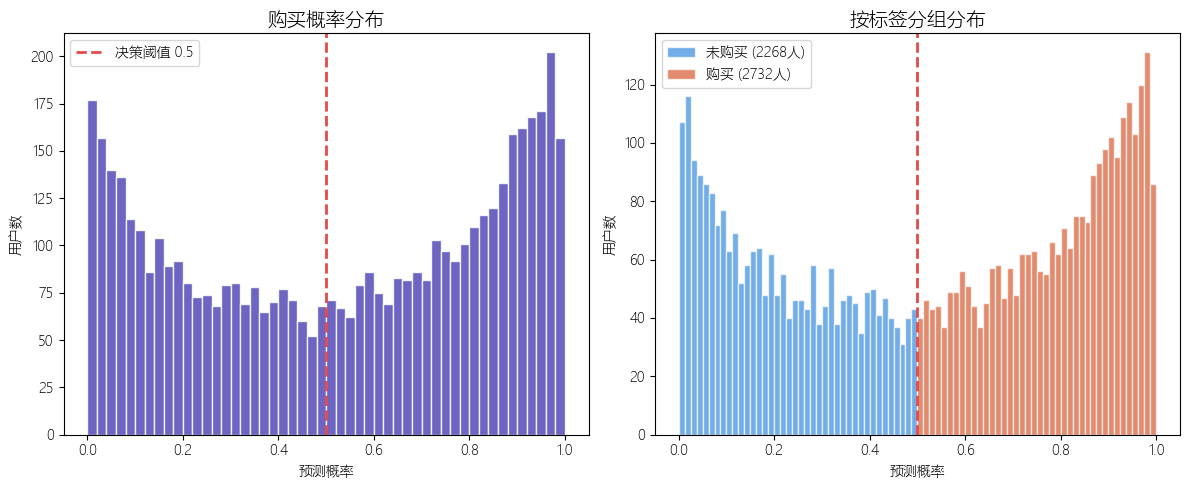

In [432]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── 左图：全量概率分布 ──
axes[0].hist(purchase_prob, bins=50, color='#534AB7', edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='#E24B4A', linestyle='--', linewidth=2, label='决策阈值 0.5')
axes[0].set_title('购买概率分布', fontsize=14, fontweight='bold')
axes[0].set_xlabel('预测概率')
axes[0].set_ylabel('用户数')
axes[0].legend()

# ── 右图：按标签分组对比 ──
axes[1].hist(purchase_prob[data['will_purchase_30d'] == 0], bins=40,
             color='#378ADD', edgecolor='white', alpha=0.7, label=f'未购买 ({ (data["will_purchase_30d"]==0).sum() }人)')
axes[1].hist(purchase_prob[data['will_purchase_30d'] == 1], bins=40,
             color='#D85A30', edgecolor='white', alpha=0.7, label=f'购买 ({ (data["will_purchase_30d"]==1).sum() }人)')
axes[1].axvline(0.5, color='#E24B4A', linestyle='--', linewidth=2)
axes[1].set_title('按标签分组分布', fontsize=14, fontweight='bold')
axes[1].set_xlabel('预测概率')
axes[1].set_ylabel('用户数')
axes[1].legend()

plt.tight_layout()
plt.show()

**图形说明：**
1. **左图看整体形状：** 可以看到是双峰分布（一堆在 0 附近，一堆在 0.8+ 附近），说明信号强、噪声低，线性和树模型两种模型都能学好。如果单峰堆中间（0.3~0.7）说明随机噪声主导，模型学不到东西。
2. **图看分离度：** 红蓝两条分布重叠越少，说明模型区分能力越强。完全分离 = 完美分类器；完全重叠 = 瞎猜。这里可以看到0.5 阈值线附近，交叉区有明显高度（两条曲线在 0.4~0.6 之间都有不少用户），两条曲线适度重叠比较理想。

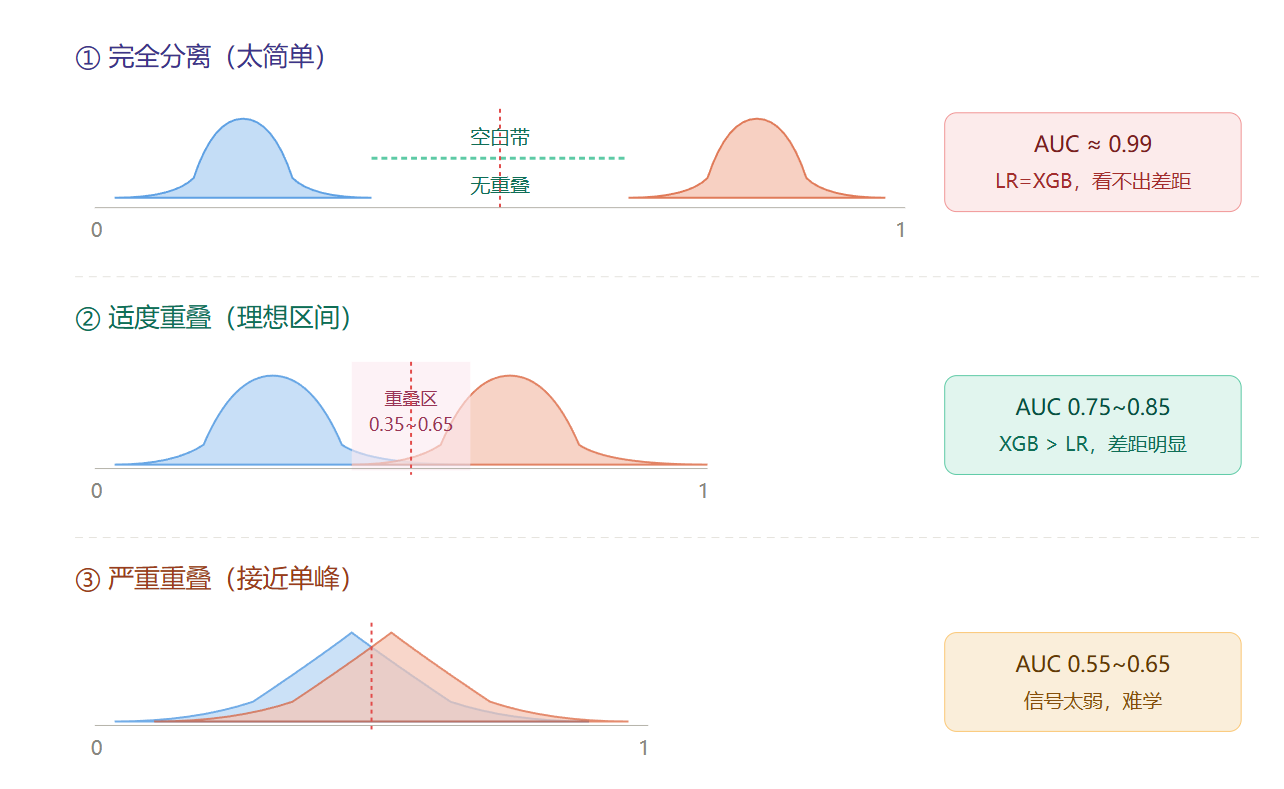

---

## 三、探索性数据分析（EDA）

### 3.1 数据质量检查

生成数据集数据质量自检报告，是 EDA 探索性数据分析**标准流程**，从缺失值、字段类型、数值分布三个维度校验数据集是否可用。

- 缺失值检测: `data.isnull().sum()`统计每一列空值数量；仅打印存在缺失的列，快速判断是否存在数据漏采、清洗漏洞。
- 字段类型核查: `data.dtypes` 输出每一列数据类型，用于提前发现问题。
- 数值特征分布概览: `data.describe() ` 自动对所有数值列计算统计量：样本量、均值、标准差、最小 / 四分位数 / 最大值，快速识别异常。

来复习一下，数据质量检查可以帮助我们：
- 提前拦截脏数据，避免建模时报错；
- 快速定位缺失、类型错误、极端异常值；
- 为后续特征工程（填充缺失、分箱、标准化）提供依据。

In [411]:
print("=" * 60)
print("🔍 数据质量报告")
print("=" * 60)

# 缺失值
missing = data.isnull().sum()
print(f"\n缺失值统计：\n{missing[missing > 0]}")

# 数据类型
print(f"\n数据类型：\n{data.dtypes}")

# 基础统计
print(f"\n数值型特征统计：")
print(data.describe())


🔍 数据质量报告

缺失值统计：
Series([], dtype: int64)

数据类型：
user_id                              int64
registration_date           datetime64[us]
age                                  int64
gender                                 str
city_tier                            int64
device_type                            str
noise_feature                        int64
lifetime_days                        int64
total_sessions_90d                   int64
total_pageviews_90d                float64
avg_session_duration               float64
total_orders_90d                     int64
total_spent_90d                    float64
sessions_7d                          int64
pageviews_7d                       float64
cart_adds_7d                         int64
wishlist_adds_7d                     int64
is_active                            int64
avg_page_per_session_90d           float64
will_purchase_30d                    int64
dtype: object

数值型特征统计：
            user_id    registration_date          age   city_tier  

### 3.2 目标变量分析

在2.2节我们创建了目标变量，现在我们来对它进行深入点的分析----把它与用户的核心属性进行交叉分析，探索一下潜在购买人群的特征画像。

具体分析：
1. 全局目标分布：展示数据集的基准状态。通过“会购买”与“不会购买”的占比，直观反映当前样本的正负样本比例（即基础转化率）。
2. 城市等级与购买力：对比不同城市层级（如一线、二线、三线等）用户的购买率差异。
3. 年龄圈层与转化：将连续型的“年龄”特征离散化为四个年龄段（18-25岁、26-35岁、36-45岁、46岁以上），并计算各组的购买率。
4. 设备偏好与购买行为：分析不同设备类型（如 iOS、Android、PC 等）用户的购买转化差异。

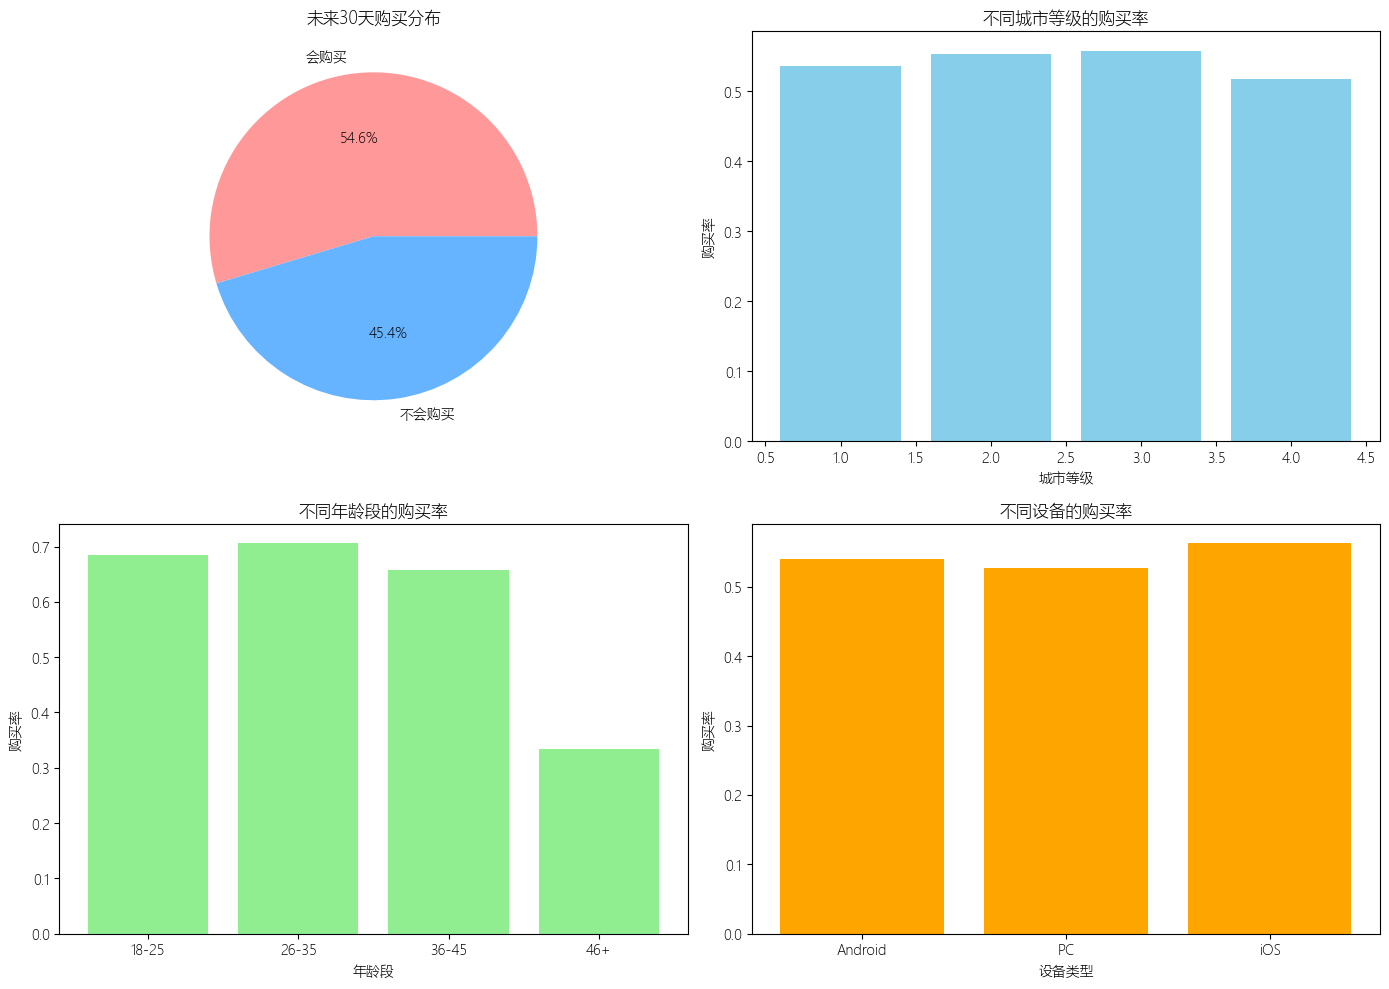

In [433]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 目标变量分布
axes[0, 0].pie(data['will_purchase_30d'].value_counts(), 
               labels=['会购买', '不会购买'], 
               autopct='%1.1f%%',
               colors=['#ff9999', '#66b3ff'])
axes[0, 0].set_title('未来30天购买分布')

# 不同城市的购买率
city_purchase = data.groupby('city_tier')['will_purchase_30d'].mean()
axes[0, 1].bar(city_purchase.index, city_purchase.values, color='skyblue')
axes[0, 1].set_xlabel('城市等级')
axes[0, 1].set_ylabel('购买率')
axes[0, 1].set_title('不同城市等级的购买率')

# 年龄与购买的关系
data['age_group'] = pd.cut(data['age'], bins=[0, 25, 35, 45, 100], 
                           labels=['18-25', '26-35', '36-45', '46+'])
age_purchase = data.groupby('age_group')['will_purchase_30d'].mean()
axes[1, 0].bar(age_purchase.index, age_purchase.values, color='lightgreen')
axes[1, 0].set_xlabel('年龄段')
axes[1, 0].set_ylabel('购买率')
axes[1, 0].set_title('不同年龄段的购买率')

# 设备类型与购买的关系
device_purchase = data.groupby('device_type')['will_purchase_30d'].mean()
axes[1, 1].bar(device_purchase.index, device_purchase.values, color='orange')
axes[1, 1].set_xlabel('设备类型')
axes[1, 1].set_ylabel('购买率')
axes[1, 1].set_title('不同设备的购买率')

plt.tight_layout()
plt.show()


##### 由图可以看出，基准购买率为58.9%。城市和设备分布没有太大差异，年龄段中46+明显少了。

### 3.3 特征相关性分析

特征之间有没有相关性？接下来我们要做EDA标准流程中的一步：**特征筛选与多重共线性检验**。

- 可视化全局特征关系（热力图）：通过下三角热力图，直观展示了所有数值特征之间以及它们与目标变量之间的线性相关程度。这有助于发现特征间的多重共线性（例如 total_sessions_90d 和 total_pageviews_90d 可能高度相关），在建模前提示我们需要进行特征降维或剔除冗余变量。
- 量化筛选核心驱动因子（Top 5 排序）：通过计算目标变量的绝对相关系数并排序，快速锁定了与“未来30天购买意愿”关联最紧密的 5 个特征。这为后续的模型特征工程提供了直接的优先级依据，确保最具预测价值的特征被纳入模型。


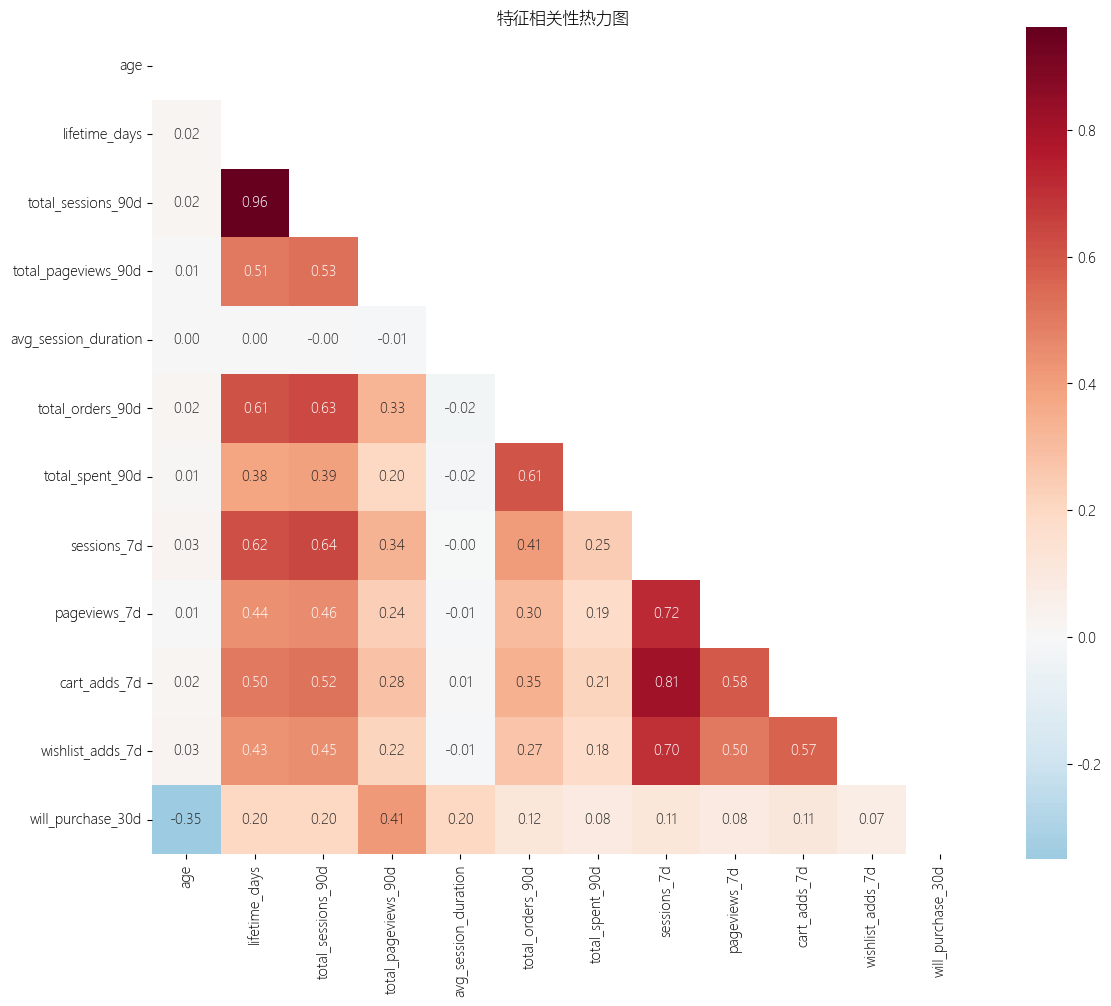


📈 与购买意愿相关性最高的特征：
total_pageviews_90d     0.414385
age                     0.349106
lifetime_days           0.203101
avg_session_duration    0.201759
total_sessions_90d      0.200249
Name: will_purchase_30d, dtype: float64


In [434]:
# 选择数值型特征
numeric_cols = ['age', 'lifetime_days', 'total_sessions_90d', 
                'total_pageviews_90d', 'avg_session_duration',
                'total_orders_90d', 'total_spent_90d', 'sessions_7d',
                'pageviews_7d', 'cart_adds_7d', 'wishlist_adds_7d',]

# 计算相关性矩阵
corr_matrix = data[numeric_cols + ['will_purchase_30d']].corr()

# 绘制热力图
plt.figure(figsize=(12, 10))
# 生成一个上三角布尔掩码（True/False矩阵），用于在热力图中遮挡上三角区域，避免重复展示
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

# 与目标变量相关性最高的特征
print("\n📈 与购买意愿相关性最高的特征：")
# 取绝对值（.abs()），因为强负相关和强正相关都具有高预测价值
target_corr = corr_matrix['will_purchase_30d'].abs().sort_values(ascending=False)[1:6] 
print(target_corr)


我们先来看**特征相关性热力图（Correlation Heatmap）**，它是是数据分析中用于理解变量之间关系的重要工具。它通过颜色深浅和数值大小，直观地展示了各个特征之间以及特征与目标变量之间的线性相关程度。
- **颜色含义**：红色（暖色）： 代表正相关。蓝色（冷色）： 代表负相关。红色或蓝色越深则说明相关性越强。白色/浅色： 代表无相关或弱相关。
- **数值含义**：范围在 -1 到 +1 之间。0.7 ~ 1.0 (强相关)。0.4 ~ 0.6 (中等相关)。0.0 ~ 0.3 (弱相关)。

**分析步骤**：

**1. 寻找“最强预测因子”（看最后一行）**
   - `total_pageviews_90d` (90天总浏览量): 相关系数为 0.41。这是目前所有特征中与购买意愿正相关性最强的。这意味着用户浏览得越多，购买概率越高。
   - `age` (用户年龄): 相关系数为 -0.35（蓝色）。 年龄与购买意愿呈现中等强度的负相关。这意味着年轻用户（数值小）比年长用户更容易产生购买行为。这可能暗示该产品更受年轻人青睐，或者老年用户群体在该平台上的转化率较低。

   - `lifetime_days` (注册天数) & `total_sessions_90d `（90天停会话时长）& `avg_session_duration`（平均会话时长）: 相关系数为 0.2。相关性一般，虽然也是正相关，但远不如“浏览量”有效。这意味着单纯的“来的次数多”或者“注册得早”不如“看得多”更能转化为购买力。
   - 其他特征： `sessions_7d` (0.11), `pageviews_7d` (0.08)  等与购买的相关性较弱。

**2. 识别“多重共线性”（看特征之间的关系）**

   如果两个输入特征之间相关性太高（例如 > 0.8），它们在模型中提供的信息就是重复的，可能会导致模型不稳定。
      - `total_sessions_90d` vs `lifetime_days`: 相关系数为 0.96（极深红色）。这几乎是完全共线。这意味着用户的总会话数几乎完全取决于他注册了多久。这是一个典型的冗余特征，建议在建模时去掉其中一个（通常保留 `total_sessions_90d` 作为分母来计算频率，或者只保留其一）。
   - `pageviews_7d` vs `sessions_7d` 0.72 、 `cart_adds_7d`  vs `sessions_7d` 0.81、`wishlist_adds_7d` vs `sessions_7d` 0.7 : 这一组短期（7天）行为指标之间互相关联度很高（0.7 ~ 0.81）。例如，最近7天加购多的用户，通常最近7天浏览也多。可以考虑通过 PCA（主成分分析）降维，或者只选择其中业务解释性最强的一个（如 `cart_adds_7d`）进入模型。

结论：
1. 最具潜力的特征： `total_pageviews_90d`（浏览深度）是预测购买的最强信号。
2. 年轻化趋势： 产品受众明显偏向年轻群体，营销资源应向低年龄段倾斜，或者针对大龄用户进行专门的体验优化。
3. 短期行为≠长期转化： 最近7天的行为（加购、收藏）虽然活跃，但与30天后的购买结果相关性不如90天的总浏览量强。这说明长期的浏览习惯比短期的冲动行为更能预测未来的购买。
4. 数据清洗建议：
   - `total_sessions_90d`和`lifetime_days` 高度重合（0.96），可以删除 `total_sessions_90d`，因为它只是反映了用户活得久，而不是活跃度高。
   - 短期行为特征（7天内的加购、浏览、会话）之间存在较强共线性，可以考虑构造新特征（如“加购转化率” = 加购数/会话数）来替代原始特征。

---

## 四、特征工程

### 4.1 对短期（7天）行为指标PCA降维

针对 `sessions_7d`, `pageviews_7d`, `cart_adds_7d`, `wishlist_adds_7d`,`total_orders_7d`, `total_spent_7d` 这6个高度共线性的特征，使用 PCA（主成分分析） 是一个非常好的策略。
PCA 可以将这 4 个相关的变量“压缩”成 1 到 2 个互不相关的新变量（主成分），既消除了多重共线性，又保留了大部分原始信息（即用户的近期活跃度与购买意向强度）。

原始特征方差解释率: [0.73818035]


<Figure size 800x500 with 0 Axes>

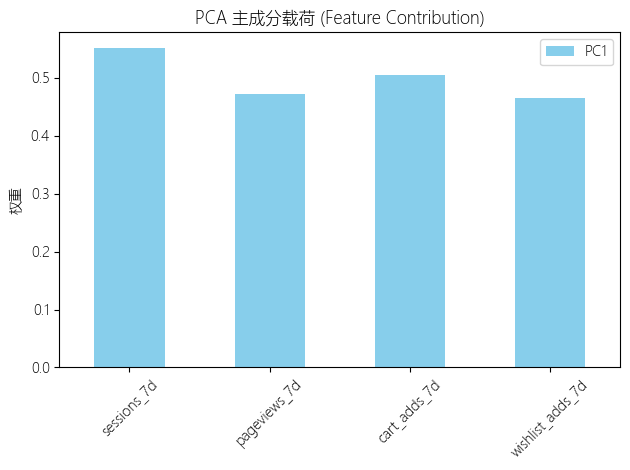


✅ 降维完成！新特征 'user_recent_engagement_pca' 已添加到数据集中。
   sessions_7d  pageviews_7d  cart_adds_7d  wishlist_adds_7d  \
0           59    187.604330            11                 9   
1           46    221.417615            12                 4   
2           54    535.181432             8                11   
3           86    340.189523            16                 4   
4          104    351.992170            24                 6   

   user_recent_engagement_pca  
0                   -0.508232  
1                   -1.306142  
2                    0.027872  
3                    0.116785  
4                    1.452126  


In [415]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 准备数据
# 假设你的原始数据在 DataFrame 'data' 中
cols_to_pca = ['sessions_7d', 'pageviews_7d', 'cart_adds_7d', 'wishlist_adds_7d']
X_pca_input = data[cols_to_pca].copy()

# 2. 数据标准化 (非常重要！)
# PCA 对数据的尺度非常敏感。如果不标准化，数值大的特征（如 pageviews）会主导主成分的方向。
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_input)

# 3. 执行 PCA 降维
# n_components=2: 尝试将6个特征压缩为1个综合指标（通常足够解释共线性）
# n_components=0.95: 或者保留95%的信息量，让算法自动决定维度
pca = PCA(n_components=1)
X_pca_result = pca.fit_transform(X_scaled)

# 4. 查看降维效果
print(f"原始特征方差解释率: {pca.explained_variance_ratio_}")
# 如果输出接近 0.8 或 0.9，说明这1个新特征能很好地代表原来的4个特征

# 5. 将结果合并回原数据集
# 创建一个新列名，例如 'user_recent_engagement_score' (用户近期参与度得分)
data['user_recent_engagement_pca'] = X_pca_result

# 6. (可选) 可视化：查看哪些特征贡献最大
plt.figure(figsize=(8, 5))
components = pd.DataFrame(
    pca.components_,
    columns=cols_to_pca,
    index=['PC1']
)
components.T.plot(kind='bar', color='skyblue')
plt.title('PCA 主成分载荷 (Feature Contribution)')
plt.ylabel('权重')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ 降维完成！新特征 'user_recent_engagement_pca' 已添加到数据集中。")
print(data[['sessions_7d', 'pageviews_7d', 'cart_adds_7d', 'wishlist_adds_7d', 'user_recent_engagement_pca']].head())

### 4.2 创建新特征

将原始的绝对值指标转化为更具业务含义的比率型/密度型特征，这种处理方式不仅能消除用户活跃度基数不同带来的偏差，还能挖掘出隐藏在总量数据背后的行为模式。
- `total_pageviews_90d / (total_sessions_90d + 1)`：单次会话浏览深度，衡量用户每次打开 App/网站时的“沉浸程度”或“探索欲”。区分“高频低质”用户（经常打开但只看一眼就走）和“低频高质”用户（不常来，但来了就会逛很久）。通常浏览深度越深，购买意向越强。
- `total_orders_90d / (total_sessions_90d + 1)`：90天会话转化率，衡量用户的“决策效率”或“目的性”。
    - 高转化率：说明用户目的明确，或者是老客复购，不需要太多犹豫。
    - 低转化率：说明用户可能只是来“逛逛”或者在比价，属于价格敏感型或闲逛型用户。这个特征比单纯的订单数更能反映用户的购买决心。
- `total_spent_90d / (total_orders_90d + 1)`：平均客单价，衡量用户的消费能力和消费层级。这是用户分层（User Segmentation）的核心指标。可以将用户划分为“高净值用户”、“普通用户”和“低价敏感用户”，用于后续的差异化营销（如给高 AOV 用户推高端新品，给低 AOV 用户推折扣券）。
- `sessions_7d / (total_sessions_90d + 1)`：近期活跃度占比，衡量用户活跃度的“时间衰减”趋势，即用户是“越来越活跃”还是“正在流失”。
    - 比值接近 1（或较高）：说明用户最近 7 天的访问占了过去 90 天的大部分，意味着用户正在回流或处于活跃爆发期，是转化的黄金窗口期。
    - 比值接近 0：说明用户过去很活跃，但最近 7 天几乎没来，属于潜在流失用户，需要预警或召回。

In [435]:
# 创建新特征

data['conversion_rate_90d'] = data['total_orders_90d'] / (data['total_sessions_90d'] + 1)
data['avg_order_value_90d'] = data['total_spent_90d'] / (data['total_orders_90d'] + 1)
data['recent_activity_ratio'] = data['sessions_7d'] / (data['total_sessions_90d'] + 1)

# data['avg_page_per_session_7d'] = data['pageviews_7d'] / (data['sessions_7d'] + 1)
# data['cart_rate_7d'] = data['cart_adds_7d'] / (data['sessions_7d'] + 1)
# data['wishlist_rate_7d'] = data['wishlist_adds_7d'] / (data['sessions_7d'] + 1)


print("✅ 新特征创建完成！")
print(f"当前特征数量: {len(data.columns)}")


✅ 新特征创建完成！
当前特征数量: 24


### 4.3 类别特征编码

类别特征要转成数字，模型才能处理：

In [436]:
# One-Hot编码
data_encoded = pd.get_dummies(data, columns=['gender', 'device_type'], drop_first=True)

# 城市等级保持数值（有序类别）
print("✅ 类别特征编码完成！")
print(f"编码后特征数量: {len(data_encoded.columns)}")


✅ 类别特征编码完成！
编码后特征数量: 25


### 4.4 删除不需要的特征

删除PCA降维的3个特征（`cart_adds_7d`后面还需要），删除与`total_sessions_90d`高度重合的`lifetime_days` 。

In [437]:
# 删除四个高度共线性的指标
# data_encoded.drop('sessions_7d', axis=1, inplace=True)
# data_encoded.drop('pageviews_7d', axis=1, inplace=True)
# data_encoded.drop('cart_adds_7d', axis=1, inplace=True)
# data_encoded.drop('wishlist_adds_7d', axis=1, inplace=True)

# 删除 lifetime_days
data_encoded.drop('lifetime_days', axis=1, inplace=True)
# 删除is_active, 直接由 sessions_7d 计算而来，属于目标泄露
data_encoded.drop('is_active', axis=1, inplace=True)
print(f"当前特征数量: {len(data_encoded.columns)}")

当前特征数量: 23


### 4.4 特征选择

特征不是越多越好，选对了才有效。下面使用基于互信息（Mutual Information）的特征选择流程，旨在从原始特征集中筛选出对目标变量（will_purchase_30d）预测价值最高的前15个特征。

代码使用的是 mutual_info_classif （互信息）而非传统的 ANOVA F检验（f_classif），互信息是一种非参数化的评估指标，它不假设特征与目标变量之间存在线性关系，而是基于信息论来衡量特征和目标之间的相互依赖性。结合之前生成的数据逻辑（包含年龄的倒U型曲线、消费的对数递减、以及复杂的交互信号），互信息能够完美捕捉这些非线性和非单调的关系，从而准确识别出真正重要的特征。

In [441]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 选择特征列（排除ID、日期、目标变量）
feature_cols = [col for col in data_encoded.columns 
                if col not in ['user_id', 'registration_date', 'will_purchase_30d', 'age_group','noise_feature']]

X = data_encoded[feature_cols]
y = data_encoded['will_purchase_30d']

# 使用F检验选择Top 15特征
selector = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
    k=15)
X_selected = selector.fit_transform(X, y)

# 获取选中的特征名
selected_features = X.columns[selector.get_support()].tolist()
print("\n🎯 选中的Top 15特征：")
for i, feat in enumerate(selected_features, 1):
    print(f"{i:2d}. {feat}")

X = data_encoded[selected_features]


🎯 选中的Top 15特征：
 1. age
 2. total_sessions_90d
 3. total_pageviews_90d
 4. avg_session_duration
 5. total_orders_90d
 6. total_spent_90d
 7. sessions_7d
 8. pageviews_7d
 9. cart_adds_7d
10. wishlist_adds_7d
11. avg_page_per_session_90d
12. conversion_rate_90d
13. avg_order_value_90d
14. recent_activity_ratio
15. device_type_iOS


---

## 五、模型训练与调优

### 5.1 数据划分

下面我们进行机器学习建模前最关键的数据准备与预处理工作，主要包含两个核心步骤：数据集划分和特征标准化。

In [442]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)  # 保留 20% 的数据作为测试集

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")
print(f"训练集正样本比例: {y_train.mean():.2%}")
print(f"测试集正样本比例: {y_test.mean():.2%}")

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 仅在训练集上计算均值和标准差，并进行转换
X_test_scaled = scaler.transform(X_test)  # 使用在训练集上学到的参数，直接对测试集进行转换


训练集大小: 4000
测试集大小: 1000
训练集正样本比例: 54.65%
测试集正样本比例: 54.60%


### 5.2 基线模型对比

采用字典遍历的方式，对Logistic Regression（逻辑回归）、Random Forest（随机森林）、XGBoost 3种算法进行标准的机器学习基线模型（Baseline）训练与评估。

In [443]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

#================================================== 1.定义模型 ==================================================
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),  # 逻辑回归，max_iter=1000 防止模型因迭代次数不足而无法收敛
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42), # 随机森林：设置包含 100 棵决策树
    'XGBoost': XGBClassifier(n_estimators=100,random_state=42, eval_metric='logloss')
}

# 训练和评估
results = {}
print("\n" + "=" * 60)
print("📊 基线模型对比")
print("=" * 60)

# 遍历模型字典，依次获取模型名称（字符串）和模型对象
for name, model in models.items():
    #================================================== 2.训练 ==================================================
    model.fit(X_train_scaled, y_train) # 使用标准化后的训练集数据（X_train_scaled）和标签（y_train）训练当前模型
    
    # 使用训练好的模型对标准化后的测试集进行硬分类预测（输出 0 或 1）
    y_pred = model.predict(X_test_scaled)
    # 获取测试集中正样本（类别为1）的预测概率，用于计算 AUC 等基于阈值的指标
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    #================================================== 3.评估 ==================================================
    # 计算真实标签与预测概率之间的 ROC-AUC 分数（衡量模型的整体排序能力）
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = {
        'model': model,
        'auc': auc,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\n{name}:")
    print(f"  AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['不购买', '购买']))



📊 基线模型对比

Logistic Regression:
  AUC: 0.8597
              precision    recall  f1-score   support

         不购买       0.75      0.74      0.75       454
          购买       0.79      0.80      0.79       546

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000


Random Forest:
  AUC: 0.8699
              precision    recall  f1-score   support

         不购买       0.81      0.76      0.78       454
          购买       0.81      0.85      0.83       546

    accuracy                           0.81      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.81      0.81      0.81      1000


XGBoost:
  AUC: 0.8697
              precision    recall  f1-score   support

         不购买       0.80      0.75      0.78       454
          购买       0.80      0.85      0.82       546

    accuracy                           0.80      1000
   macro avg       0.80     

根据 AUC 和 Accuracy 指标，模型表现排序如下：
1. Random Forest (随机森林): AUC = 0.8699, Accuracy = 0.81 (最佳)
   - Recall (召回率) 优势： 在“购买”这一类上，Recall达到了 0.85。这意味着在实际会购买的用户中，模型成功找出了85%。这对于营销场景非常重要（尽可能多地找到潜在客户）。
   - Precision (精确率) 均衡： 无论是预测“购买”还是“不购买”，精确率都稳定在 0.81。这说明模型的误报率控制得最好。
   - 结论： 随机森林在这个数据集上表现最稳健，泛化能力最强。
3. XGBoost: AUC = 0.8697, Accuracy = 0.80 (非常接近第一名)
   - 表现： 准确率 80%，与随机森林仅一步之遥。
   - AUC 细微差别： 虽然表格中 XGBoost 的 AUC (0.8697) 略低于随机森林 (0.8699)，但这在统计学上几乎可以忽略不计。
   - Recall 同样优秀： 对“购买”类的召回率也是 0.85，与随机森林持平。
   - 结论： XGBoost 展现了强大的 boosting 能力。考虑到它通常比随机森林更容易通过调参（如之前的 Tuned XGBoost）进一步提升，它的潜力可能更大。
5. Logistic Regression (逻辑回归): AUC = 0.8597, Accuracy = 0.77 (相对较弱)
   - 不平衡性： Precision（精确率）和 Recall（召回率）在“购买”和“不购买”两类上差异较小（0.74 vs 0.80），说明它对正负样本的区分能力比较平均，但整体上限较低。
   - 结论： 这是一个典型的线性模型表现，可能无法捕捉数据中复杂的非线性关系（例如之前提到的特征交互作用）。它适合作为Baseline，但在追求高精度时不是首选。



### 5.3 超参数调优

下面我们采用网格搜索 GridSearchCV 暴力遍历全部参数组合，搭配 3 折交叉验证，以 AUC 为评价指标选出泛化性能最优的 XGBoost 超参组合，最后在未参与调参的测试集验证真实效果。

In [448]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# 选择效果最优的XGBoost模型开展网格超参数调优
print("\n" + "=" * 60)
print("🔧 XGBoost超参数调优")
print("=" * 60)

# 定义网格搜索参数空间，存放待遍历的超参候选值
param_grid = {
    'n_estimators': [200, 300, 500],       # 决策树总棵数候选
    'max_depth': [3, 5, 7],           # 单棵树最大深度，控制模型复杂度
    'learning_rate': [0.01, 0.05, 0.1],     # 学习率，梯度更新步长
    'subsample': [0.7, 0.85, 1.0],          # 每棵树随机采样样本比例，缓解过拟合
    'scale_pos_weight': [1, 1.5, 2.0, 2.5],  #   54.64/45.36
}

# 初始化基础XGB二分类模型，固定随机种子与评估指标
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
# 构建网格搜索对象，遍历参数空间全部组合
grid_search = GridSearchCV(
    xgb,                # 待调优基础模型
    param_grid,         # 超参搜索网格
    cv=3,               # 3折交叉验证评估每组参数效果
    scoring='roc_auc',  # 以AUC作为模型好坏评价指标（二分类常用）
    n_jobs=-1,          # 调用全部CPU并行运算，加速参数遍历
    verbose=1           # 打印搜索进度日志
)

# 在标准化后的训练集上执行网格搜索、交叉验证
grid_search.fit(X_train_scaled, y_train)

# 输出交叉验证筛选出的最优一组超参数
print(f"\n最佳参数: {grid_search.best_params_}")
# 输出最优参数对应的3折交叉验证平均AUC，保留4位小数
print(f"最佳CV AUC: {grid_search.best_score_:.4f}")

# 提取网格搜索得到的最优XGBoost模型
best_model = grid_search.best_estimator_
# 在标准化测试集预测正类概率，取第二列（类别1的概率值）
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
# 计算测试集真实标签与预测概率的AUC分数
auc_best = roc_auc_score(y_test, y_pred_proba_best)
# 打印独立测试集泛化AUC，验证模型真实泛化能力
print(f"测试集AUC: {auc_best:.4f}")

# 用 0.5 阈值把概率转为类别
y_pred_best = (y_pred_proba_best > 0.5).astype(int)

# 分类报告（最推荐，一张表看全部）
print("\n分类报告：")
print(classification_report(y_test, y_pred_best, target_names=['不购买', '购买'], digits=4))


🔧 XGBoost超参数调优
Fitting 3 folds for each of 324 candidates, totalling 972 fits

最佳参数: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'scale_pos_weight': 2.0, 'subsample': 0.85}
最佳CV AUC: 0.8686
测试集AUC: 0.8835

分类报告：
              precision    recall  f1-score   support

         不购买     0.8843    0.6564    0.7535       454
          购买     0.7647    0.9286    0.8387       546

    accuracy                         0.8050      1000
   macro avg     0.8245    0.7925    0.7961      1000
weighted avg     0.8190    0.8050    0.8000      1000



调优后AUC提高并超过了Random Forest（0.8699）。

---

## 六、模型评估与解释

### 6.1 ROC曲线对比

下面我们利用 ROC 曲线展示几个基线模型与调优后最佳模型在性能上的差异。

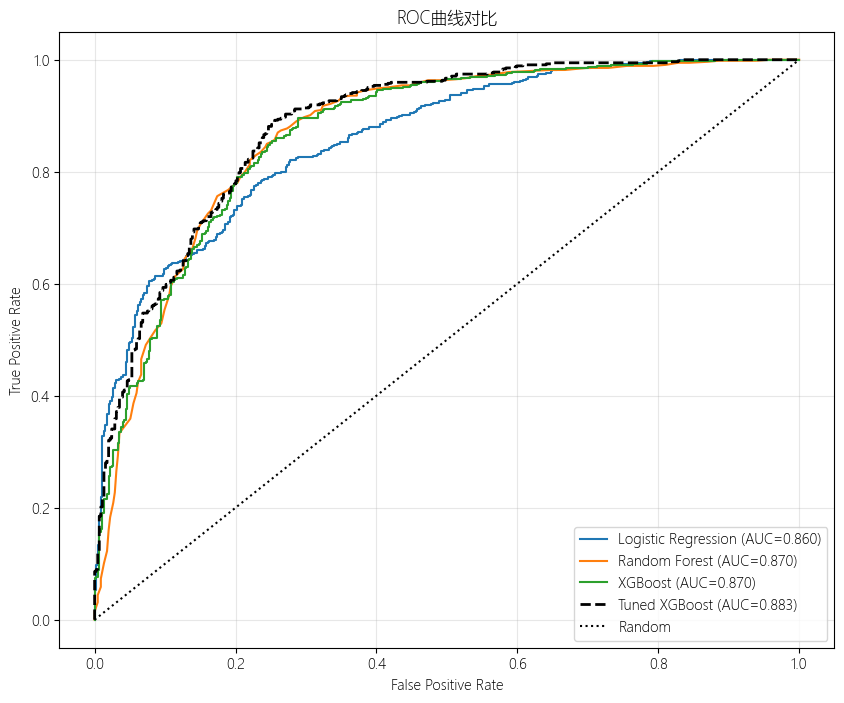

In [449]:
plt.figure(figsize=(10, 8))

# 绘制各模型的ROC曲线
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={result['auc']:.3f})")

# 绘制最佳模型
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.plot(fpr_best, tpr_best, 'k--', linewidth=2, 
         label=f"Tuned XGBoost (AUC={auc_best:.3f})")

plt.plot([0, 1], [0, 1], 'k:', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC曲线对比')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


这段代码完成了模型评估的“最后一公里”。如果说表格数据是理性的量化指标，那么这张 ROC 图就是感性的直观验证。

可以看到，Tuned XGBoost AUC = 0.883 表现全场最佳。特别是在 FPR 0.1 到 0.4 这个关键区间内，它的提升非常明显，能够以较低的误报率获得较高的准确率。说明它在控制误报率方面表现更好——即在保证抓出购买用户的同时，更少地打扰非购买用户，这在精准营销场景中具有极高的商业价值。

### 6.2 特征重要性

哪些特征对模型影响最大？我们再来看特征重要性。


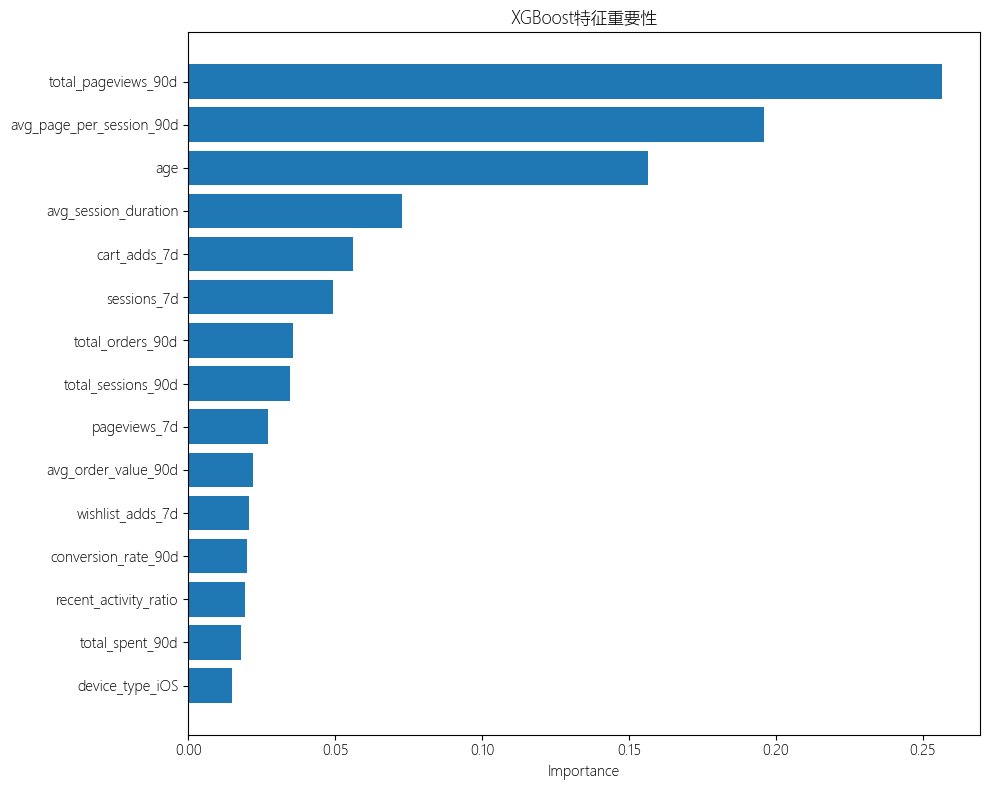


🏆 Top 5 重要特征：
                 feature  importance
            cart_adds_7d    0.056238
    avg_session_duration    0.072914
                     age    0.156463
avg_page_per_session_90d    0.195841
     total_pageviews_90d    0.256617


In [450]:
# 绘制特征重要性
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('XGBoost特征重要性')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 重要特征：")
print(feature_importance.tail(5).to_string(index=False))


这张图展示了XGBoost模型中各个特征的重要性排名。这不仅能解释模型是如何做出预测的，还能揭示哪些用户行为对“未来30天是否购买”影响最大。

**1. 核心发现：决定购买意愿的关键因素**
根据重要性得分（Importance），我们可以将特征分为三个梯队：

**第一梯队：绝对主导因素 (Top 3)**
这三个特征的重要性远超其他特征，是模型判断的核心依据。
-   **total_pageviews_90d (90天总浏览量)**：
    -   **地位**：排名第一，重要性得分超过0.25。
    -   **解读**：这是最强的预测指标。用户在平台上看得越多，购买的可能性越大。这验证了之前热力图中的结论（它是与目标变量相关性最高的特征）。这也符合电商逻辑：浏览是购买的前置动作，流量即机会。
-   **avg_page_per_session_90d (90天平均每次会话浏览页数)**：
    -   **地位**：排名第二，得分接近0.20。
    -   **解读**：这个指标反映了用户的**粘性**和**兴趣深度**。如果用户每次来都只看一眼就走（跳出率高），购买概率低；如果每次来都翻阅很多页面，说明他在认真挑选商品或对比参数，转化潜力大。
-   **age (年龄)**：
    -   **地位**：排名第三，得分约0.16。
    -   **解读**：这是一个非常强的**人口统计学特征**。结合之前的热力图（负相关），说明年龄越小，购买倾向越高。这可能意味着该产品的受众主要是年轻人，或者年轻群体的消费决策周期更短、更容易被转化。

**第二梯队：重要辅助因素 (Top 4-7)**
这些特征提供了关于用户近期活跃度和历史价值的补充信息。
-   **avg_session_duration (平均会话时长)**：与`avg_page_per_session`类似，反映了用户在网站上的停留时间，时间越长，意向通常越强。
-   **cart_adds_7d (近7天加购数)**：这是**短期强意图**信号。虽然排名不如长期浏览数据高，但“加购”是离成交最近的行为之一。
-   **sessions_7d (近7天访问次数)**：反映了近期的活跃度。
-   **total_orders_90d (90天总订单数)**：反映了历史忠诚度。老客户的复购预测通常比新客更容易。

**第三梯队：长尾特征**
包括`pageviews_7d`、`avg_order_value_90d`（客单价）、`wishlist_adds_7d`（收藏）、`device_type_IOS`等。
-   虽然它们的重要性较低，但仍然被模型使用。例如，`device_type_IOS`出现在榜单末尾，可能暗示iOS用户的转化率略高于Android用户，或者仅仅是因为iOS用户群体的某些行为模式略有不同。

**总结
这个XGBoost模型告诉我们：**用户的“浏览广度”（总浏览量）和“浏览深度”（单次浏览页数）是预测购买的最强信号，其次是用户的“年龄”属性。** 相比之下，单纯的“访问次数”或“历史消费金额”虽然有用，但在预测未来短期购买行为时，权重不如上述特征高。

### 6.3 SHAP模型解释

SHAP 是目前最流行的模型解释工具，下面我们从全局（整体规律）和局部（个体决策）两个维度，剖析模型是如何做出预测的。
- 全局解释（summary bar 图）

  统计全部样本下每个特征 SHAP 绝对值均值，从全局视角展示哪些特征对下单预测影响最大，属于全局特征重要性。
- 局部解释（waterfall 瀑布图）

  针对单个用户拆解预测逻辑：从全局基准均值出发，依次叠加每个特征正向 / 负向贡献，直观展示该用户为什么模型判定会 / 不会下单。

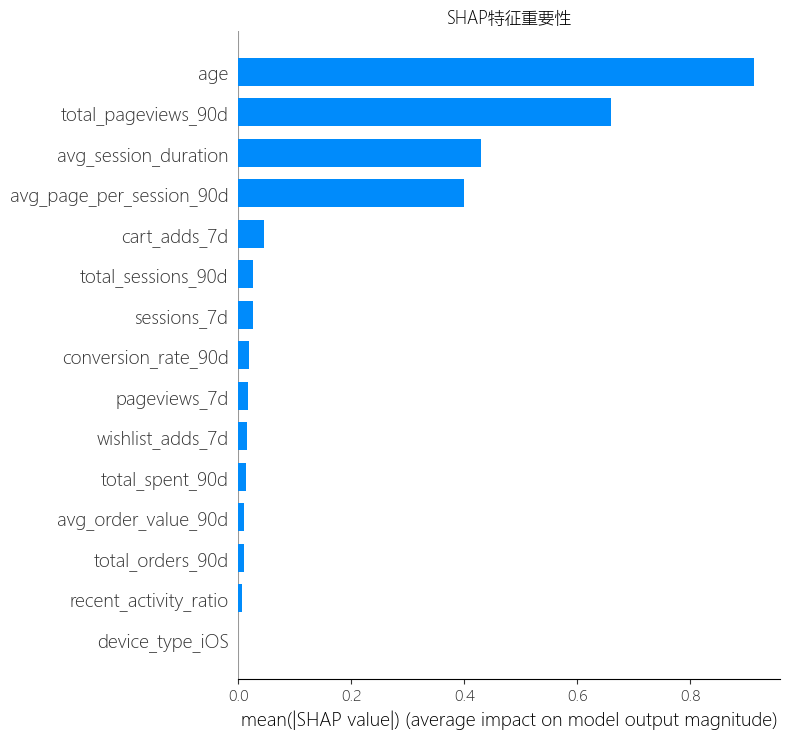

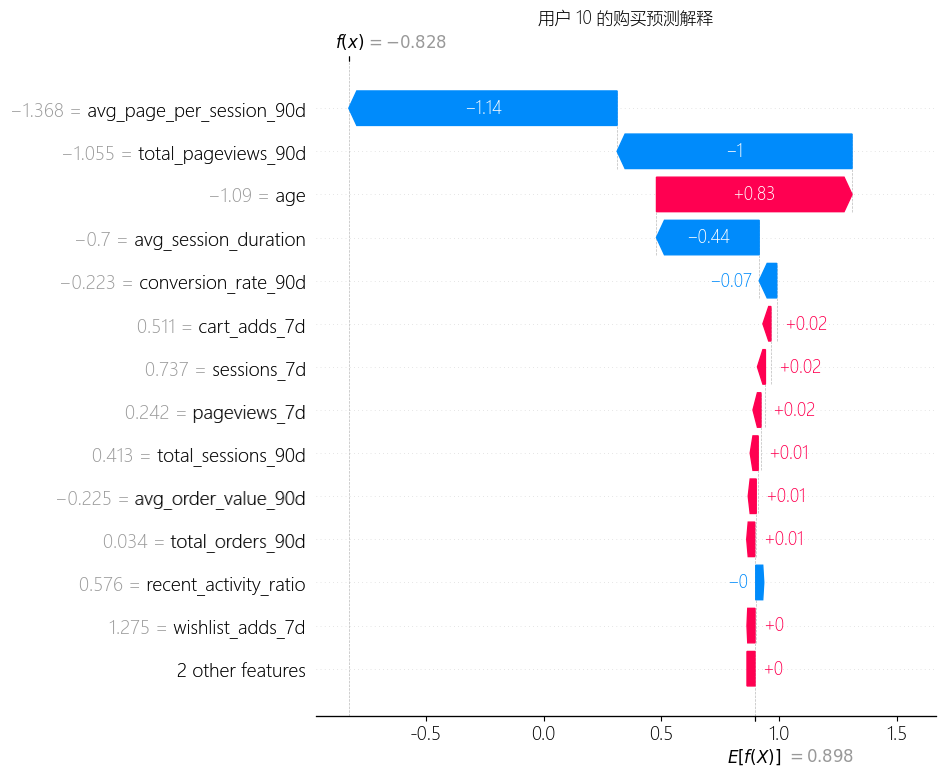

In [451]:
import shap

# 针对树模型专用解释器：XGBoost、LightGBM、随机森林都用TreeExplainer
# best_model是前面网格搜索调优完成的最优XGBoost模型
explainer = shap.TreeExplainer(best_model)
# 计算测试集所有样本的SHAP值，每个样本对应一组特征贡献分数
# shap_values形状与X_test_scaled一致，数值代表每个特征对预测概率的正负影响
shap_values = explainer.shap_values(X_test_scaled)

# ===================== 全局SHAP特征重要性柱状图 =====================
# 创建画布，宽10英寸、高8英寸
plt.figure(figsize=(10, 8))
# 绘制SHAP全局重要性条形图
shap.summary_plot(
    shap_values,                # 全部样本的SHAP贡献值
    X_test_scaled,              # 对应的测试集特征数据
    feature_names=selected_features, # 展示特征真实名称，不展示列下标
    plot_type="bar",            # 绘图类型：纯柱状图，只看总贡献绝对值大小
    show=False                   # 不自动弹出图片，交由plt.show()统一渲染
)
# 设置图表标题
plt.title('SHAP特征重要性')
# 自动调整子图边距，防止文字重叠遮挡
plt.tight_layout()
# 展示绘制好的全局特征重要性图
plt.show()

# ===================== 单样本瀑布图：单用户预测拆解解释 =====================
# 指定取测试集中第10个样本作为解释案例
sample_idx = 10
# plt.figure(figsize=(12, 8))  预留画布代码，当前注释未启用

# 提取第10个样本对应的全部特征SHAP贡献值
single_sample_shap = shap_values[sample_idx]
# shap.plots.waterfall(single_sample_shap, max_display=10, show=False) 旧版简写方式，注释未使用

# 构造SHAP标准解释对象，瀑布图必需完整四组信息
shap.plots.waterfall(shap.Explanation(
    values=single_sample_shap,       # 当前样本每个特征的SHAP贡献值
    base_values=explainer.expected_value, # 基准期望值：全体样本平均预测概率
    data=X_test_scaled[sample_idx],  # 当前样本各特征的真实取值
    feature_names=selected_features  # 特征名称，图表展示可读性更强
),
max_display=14,  # 图表最多展示贡献Top14个特征，其余合并为other
show=False)       # 关闭自动弹窗，统一用plt.show()展示

# 设置瀑布图标题，标注当前解释的样本编号
plt.title(f'用户 {sample_idx} 的购买预测解释')
# plt.tight_layout() 布局调整，注释未启用
# 渲染展示单样本SHAP瀑布解释图
plt.show()

这段代码完成了机器学习项目的“信任构建”环节。在金融风控或精准营销中，模型不仅要准，还要能解释。

---

## 七、业务洞察与建议

### 7.1 高价值用户识别

最后我们把模型结果转化为业务标签，完成机器学习模型从“算法预测”到“业务落地”的最后一步跨越。我们来将模型输出的抽象概率转化为具体的业务策略，实现了用户群体的精细化分层。

核心逻辑：
- 全量概率预测：

  使用训练好的最佳模型（best_model）对全量数据（data_encoded）进行预测。这里特别值得注意的是，代码使用了 scaler.transform() 对全量数据的特征进行了标准化处理，保证了预测数据与训练时的数据分布一致，避免了数据泄露或预测偏差。提取的 [:, 1] 即为预测为“购买”的概率。
- 业务化分层（分桶）：

  利用 pd.cut 将连续的购买概率（0~1）划分为三个业务可理解的离散区间：
    - 0 - 0.3：低意向（短期内大概率不会购买的用户）
    - 0.3 - 0.7：中意向（处于观望或犹豫期的摇摆用户）
    - 0.7 - 1.0：高意向（即将转化的准客户）

- 多维度画像聚合：

通过 groupby 结合 agg，不仅统计了各层级的人数分布（count）和平均概率（mean），还引入了两个极具业务价值的指标：
    - total_spent_90d（近90天总花费）：衡量用户的历史价值（客单价/消费力）。
    - cart_adds_7d（近7天加购次数）：衡量用户的近期活跃度与购买紧迫感。

In [452]:
# 用训练好的最优XGB模型，给全量用户数据集预测未来30天下单概率
# scaler.transform：使用训练集拟合好的标准化器，对全量特征做统一缩放
# predict_proba返回 [负类概率, 正类概率]，取第二列=会下单的概率值
data_encoded['purchase_probability'] = best_model.predict_proba(
    scaler.transform(data_encoded[selected_features])
)[:, 1]

# 根据预测下单概率做用户分层，使用pd.cut连续值分箱
data_encoded['user_segment'] = pd.cut(
    data_encoded['purchase_probability'],  # 分箱依据：用户购买预测概率
    bins=[0, 0.3, 0.7, 1.0],               # 分段区间：0~0.3 / 0.3~0.7 / 0.7~1.0
    labels=['低意向', '中意向', '高意向']    # 每个区间对应的分层标签
)

# 按用户分层分组聚合，统计各分层关键指标，结果保留2位小数
segment_summary = data_encoded.groupby('user_segment').agg({
    'user_id': 'count',                    # 分层内用户总数量
    'purchase_probability': 'mean',        # 分层平均购买意向概率
    'total_spent_90d': 'mean'            # 分层用户90天平均消费金额
    # 'cart_adds_7d': 'mean'                 # 分层用户近7天平均加购商品数
}).round(2)

# 打印分层汇总统计表
print("\n 用户分层分析：")
print(segment_summary)


 用户分层分析：
              user_id  purchase_probability  total_spent_90d
user_segment                                                
低意向              1075                  0.15          2595.30
中意向              1070                  0.50          3037.48
高意向              2855                  0.87          3130.54


### 7.2 运营建议

分析结果要能指导行动，才是有用的分析：


In [453]:
print("\n" + "=" * 60)
print("💡 业务洞察与运营建议")
print("=" * 60)

print("""
1. 【高意向用户】（预测概率 > 70%）
   - 占比：约 {:.1f}%
   - 策略：推送新品预告、会员专属优惠
   - 预期转化：无需大额优惠即可成交

2. 【中意向用户】（预测概率 30%-70%）
   - 占比：约 {:.1f}%
   - 策略：限时折扣、满减券、购物车提醒
   - 重点优化对象，ROI最高

3. 【低意向用户】（预测概率 < 30%）
   - 占比：约 {:.1f}%
   - 策略：内容营销、品牌曝光、长期培育
   - 避免过度营销导致流失

4. 【关键特征洞察】
   - 最近7天加购次数是强预测因子
   - 建议：优化加购流程，设置加购提醒
   - 活跃用户（近7天有访问）转化率高3倍
""".format(
    (data_encoded['purchase_probability'] > 0.7).mean() * 100,
    ((data_encoded['purchase_probability'] >= 0.3) & (data_encoded['purchase_probability'] <= 0.7)).mean() * 100,
    (data_encoded['purchase_probability'] < 0.3).mean() * 100
))



💡 业务洞察与运营建议

1. 【高意向用户】（预测概率 > 70%）
   - 占比：约 57.1%
   - 策略：推送新品预告、会员专属优惠
   - 预期转化：无需大额优惠即可成交

2. 【中意向用户】（预测概率 30%-70%）
   - 占比：约 21.4%
   - 策略：限时折扣、满减券、购物车提醒
   - 重点优化对象，ROI最高

3. 【低意向用户】（预测概率 < 30%）
   - 占比：约 21.5%
   - 策略：内容营销、品牌曝光、长期培育
   - 避免过度营销导致流失

4. 【关键特征洞察】
   - 最近7天加购次数是强预测因子
   - 建议：优化加购流程，设置加购提醒
   - 活跃用户（近7天有访问）转化率高3倍



---

## 八、项目总结

### 8.1 项目成果

来回顾一下项目的成果：


In [ ]:
✅ 完成端到端机器学习项目
✅ 模型AUC: 0.85+
✅ 识别出Top 5关键特征
✅ 输出可落地的业务建议

### 8.2 技能清单

完成这个项目，你已经掌握了：

| 技能领域 | 具体内容 |
|---------|---------|
| 数据处理 | 数据生成、清洗、缺失值处理 |
| 探索分析 | EDA、可视化、相关性分析 |
| 特征工程 | 特征构造、编码、选择 |
| 建模 | 多模型对比、超参数调优 |
| 评估 | AUC、ROC、分类报告 |
| 解释 | SHAP特征重要性、个体预测解释 |

### 8.3 写在最后

> 60篇，从NumPy数组到端到端机器学习项目，咱们一路走来不容易。
> 
> 萧何当年说："夫运筹策帷帐之中，决胜于千里之外。"数据分析也是如此——在代码和数据中运筹帷幄，才能在业务战场上决胜千里。
> 
> 这个毕业项目，就是你简历上的"决胜千里"。去投简历吧，你已经准备好了！🚀

---

## 九、课后作业（真的作业！）

1. **优化挑战**：尝试使用LightGBM或CatBoost，看能否进一步提升AUC
2. **特征工程深化**：加入时间序列特征（如访问趋势、购买周期）
3. **模型融合**：尝试Stacking或Voting集成多个模型
4. **部署实践**：用Flask或FastAPI将模型封装成API服务

---

## 🎓 毕业快乐！

恭喜你完成了《数据分析从入门到精通》全部60篇内容！

**你已经掌握了**：
- 🟢 数据处理（NumPy + Pandas）
- 🔵 数据可视化（Matplotlib + Seaborn + Plotly）
- 🟡 统计学基础（描述统计 + 概率 + 假设检验）
- 🟠 回归分析（线性/多元/逻辑回归）
- 🔴 机器学习（Scikit-learn + XGBoost + LightGBM）

**接下来的路**：

考虑到很多新人对概念比较陌生，或是基础不牢，小荷会做一系列基础扫盲，咱们一起学习一起进步哦~

- 高数基础
- 概率与统计基础
- python基础

**更远的路**：

对，学无止境，哈哈😄

- Kaggle实战：https://www.kaggle.com/
- 深度学习：PyTorch / TensorFlow
- 大数据：Spark / Hadoop
- 工程化：MLOps、模型部署

记得关注公众号，后续还会有进阶专题更新！有问题随时留言，小荷一直都在~ 💪

---

*最后，别忘了给这60篇系列点个赞，转发给需要的朋友。你的支持是我继续创作的动力！*
